# MAIN ANALYSIS NOTEBOOK FOR GROUP MEETING ON 29.1.2026

In [1]:
# environment setupa
import sys; sys.path.append("..")
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from src.featurizers import StructurePropertyFeaturizer, FunctionFeaturizer
from src.sqlmodels import StructureProperty, Substituent, Structure, SubstituentProperty, StructureSubstituents
from src import utils

from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
engine = create_engine("sqlite:///{}".format("../main.db"))
session = sessionmaker(bind=engine)()
import matplotlib as mpl
c = "#F2F2F2"
mpl.rcParams["figure.facecolor"] = c
mpl.rcParams["axes.facecolor"] = c
mpl.rcParams["savefig.facecolor"] = c
plt.rcParams['font.size'] = 16
utils.define_pallet()

# Computation Performance

In [33]:
def non_planarity_modes(session):
    names = session.query(StructureProperty.property).distinct().all()
    return [x[0] for x in names if "non planarity" in x[0]]

def homa_properties(session, target="homa"):
    names = session.query(StructureProperty.property).filter(StructureProperty.source.startswith("homa")).distinct().all()
    return [x[0] for x in names if target in x[0]]

def homa_values_df(session, sids, target, avg_pyrroles):
    # reading the data from SQL
    homa_props = homa_properties(session, target=target)
    units = [None for _ in range(len(homa_props))]
    feat = StructurePropertyFeaturizer(homa_props, units, navalue=None, property_source="dft")
    homa_df = pd.DataFrame(data=feat.featurize(session, sids), columns=feat.feature_names, index=sids)
    homa_df.columns = [c.split(" ")[0] for c in homa_df.columns]
    if avg_pyrroles:
        # adding column of average pyrrole HOMA score
        pyrrole_cols = [c for c in homa_df.columns if "pyrrole" in c]
        homa_df["pyrrole_avg"] = homa_df[pyrrole_cols].mean(axis=1)
        # removing all other pyrrole columns
        # homa_df = homa_df[[c for c in homa_df.columns if not c in pyrrole_cols]]
    return homa_df

def non_planarity_df(session, sids, units, add_total_non_planarity):
    # reading the data
    modes = non_planarity_modes(session)
    mode_units = [units for _ in range(len(modes))]
    if add_total_non_planarity:
        modes.append("total out of plane (exp)")
        mode_units.append("A")
    feat = StructurePropertyFeaturizer(modes, mode_units, navalue=None, property_source="porphystruct/dft")
    return pd.DataFrame(data=feat.featurize(session, sids), columns=feat.feature_names, index=sids)

def orca_property_names(session):
    names = session.query(StructureProperty.property).filter(StructureProperty.source == "parser/base_calculation").distinct().all()
    return [x[0] for x in names]

def orca_properties_df(session, sids, source: str):
    # reading the data from SQL
    props = orca_property_names(session)
    units = [None for _ in range(len(props))]
    feat = StructurePropertyFeaturizer(props, units, navalue=None, property_source=source)
    df = pd.DataFrame(data=feat.featurize(session, sids), columns=feat.feature_names, index=sids)
    df = df.dropna()
    return df

def complex_details(session, sid):
    metal = int(session.query(StructureSubstituents.substituent).filter(StructureSubstituents.structure == sid).filter(StructureSubstituents.position == "metal").all()[0][0])
    metal_idx = int(session.query(StructureSubstituents.atom_indicis).filter(StructureSubstituents.structure == sid).filter(StructureSubstituents.position == "metal").all()[0][0]) - 1
    metal = session.query(Substituent.smiles).filter(Substituent.id == metal).all()[0][0][1:-1]
    coordination = 6 - session.query(StructureSubstituents).filter(StructureSubstituents.position == "axial").filter(StructureSubstituents.structure == sid).count()
    d_population = session.query(SubstituentProperty.value).filter(SubstituentProperty.property == "d_population").filter(SubstituentProperty.structure == sid).first()
    if d_population is not None:
        d_population = d_population[0]
    return [metal, metal_idx, coordination, d_population]

def complex_details_df(session, sids):
    feat = FunctionFeaturizer(["metal", "metal_idx", "coordination", "d_population"], complex_details, navalue=None)
    return feat.featurize(session, sids)


def fetch_data(session, sids):
    dfs = [homa_values_df(session, sids, "homa", True),
            non_planarity_df(session, sids, "A", add_total_non_planarity=True),
            complex_details_df(session, sids),
            orca_properties_df(session, sids)]
    res = pd.concat(dfs, axis=1, join="inner")
    res = res[["metal", "coordination", "pyrrole_avg", "inner_circuit", "saddling non planarity", "ruffling non planarity", "total out of plane (exp)", "HOMO-0_energy", "HOMO-1_energy", "LUMO+0_energy", "LUMO+1_energy", "HOMO-LUMO_gap"]]
    res.columns = ["metal", "coordination", "Pyrrole HOMA", "Global HOMA", "Saddling", "Ruffling", "Total out of plane", "HOMO", "HOMO-1", "LUMO", "LUMO+1", "Gap"]
    return res

def scatter_plot(x, y, ax=None, xname=None, yname=None, add_fitted_line=False, add_ideal_line=False, label=None, linecolor="r", linestyle="--"):
    if ax is None:
        ax = plt.gca()
    ax.scatter(x, y, label=label)
    if xname is not None:
        ax.set_xlabel(xname)
    if yname is not None:
        ax.set_ylabel(yname)
    if add_fitted_line:
        a, b = np.polyfit(x, y, deg=1)
        print("a=", a, "b=", b)
        fitted_x = [min(x), max(x)]
        fitted_y = [a * v + b for v in fitted_x]
        ax.plot(fitted_x, fitted_y, color=linecolor, linestyle=linestyle)
    if add_ideal_line:
        fitted_x = [min(x), max(x)]
        ax.plot(fitted_x, fitted_x, color=linecolor, linestyle=linestyle)

def get_sids(session, have_dft: bool=True, have_electronic_structure: bool=False):
    q = session.query(Structure.id)
    if have_dft:
        q = q.filter(Structure.orca_out != None)
    if have_electronic_structure:
        q = session.query(StructureProperty.structure).filter(StructureProperty.source.like("parser/S%")).distinct()
    sids = set([x[0] for x in q.all()])
    return list(sids)


In [4]:
def analyze_performance_df(df: pd.DataFrame, n_calculations: int):
    sids = get_sids(session, have_dft=False)
    # filter df to contain only valid sids
    df["sid"] = [s.split("_")[0] for s in df["name"]]
    df = df[df["sid"].isin(sids)]
    df["runtime_h"] = df["runtime"] / 3600
    df["runtime_per_electron"] = df["runtime"] / df["n_electrons"]
    plt.figure();
    plt.hist(df["runtime_h"]);
    plt.xlabel("Runtime (h)");
    plt.ylabel("Count");
    avg_runtime = df["runtime_h"].mean()
    avg_runtime_per_electron = df["runtime_per_electron"].mean()
    plt.text(0.99, 0.99, f"Avg Runtime: {avg_runtime:.2f} h\nAvg Runtime per electron: {avg_runtime_per_electron:.2f} s\nSuccessful compuations: {len(df)} / {n_calculations}", 
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right')

# Geometry comparision

in this section we compare the crystal structure geometries to the DFT calculated ones. We compare bond lengths, angles, and dihedral angles. 

## Basic geometry analysis 
compare bond length, angles and dihedrals between ORCA calculation and crystal

In [16]:
def fetch_geo_data(prefix: str) -> pd.DataFrame:
    """Fetch all the geo data from the database. as a list. note that the lists from different sources are comparable."""
    SP = StructureProperty

    # Step 3: Fetch ORCA and CRYSTAL values for these ids
    orca_df = pd.DataFrame(
        session.execute(text(f"SELECT structure, property, value FROM structure_properties WHERE structure IN (SELECT id FROM structures WHERE NOT orca_out ISNULL) AND source='geometry/orca' AND property LIKE '{prefix}%'")),
        columns=["structure", "property", "dft"]
    )

    crystal_df = pd.DataFrame(
        session.execute(text(f"SELECT structure, property, value FROM structure_properties WHERE structure IN (SELECT id FROM structures WHERE NOT orca_out ISNULL) AND source='geometry/crystal' AND property LIKE '{prefix}%'")).all(),
        columns=["structure", "property", "crystal"]
    )

    merged = pd.merge(
        orca_df,
        crystal_df,
        on=["structure", "property"],
        how="outer"
    ).sort_values(by=["structure", "property"]).reset_index(drop=True)
    return merged.dropna()

In [17]:
bonds_df = fetch_geo_data("bond")
angles_df = fetch_geo_data("angle")
dihedrals_df = fetch_geo_data("dihedral")
# print(len(df[(pd.isna(df["value_x"])) & ~(pd.isna(df["value_y"]))]))
# print(len(df[~(pd.isna(df["value_x"])) & (pd.isna(df["value_y"]))]))
# print(len(df[~(pd.isna(df["value_x"])) & ~(pd.isna(df["value_y"]))]))
# df[~(pd.isna(df["value_x"])) & (pd.isna(df["value_y"]))]

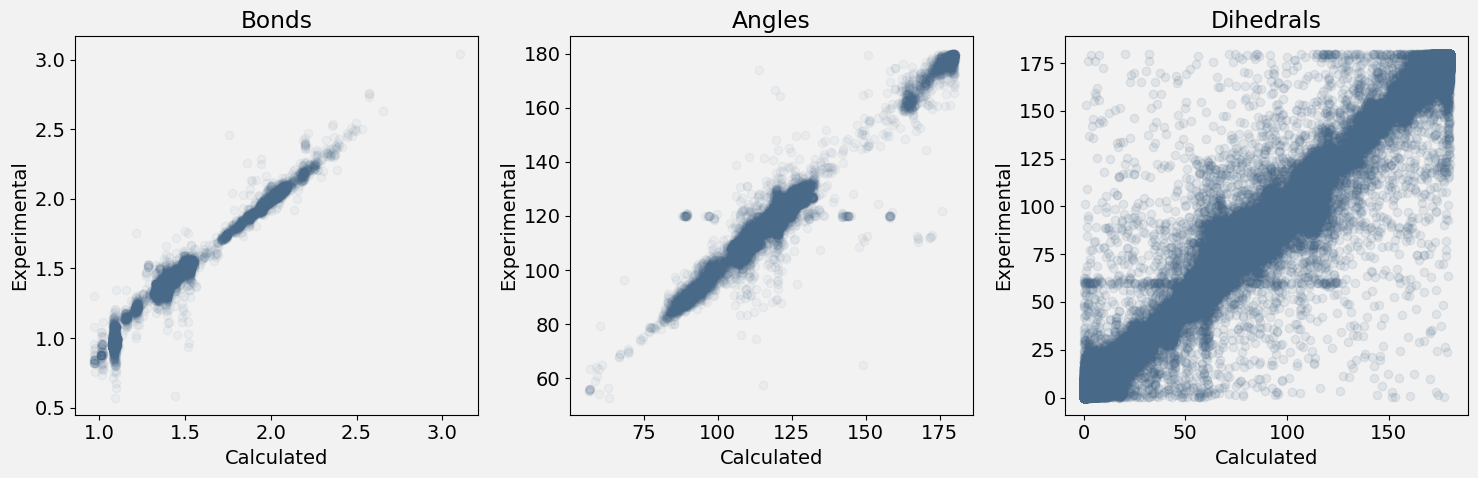

In [21]:
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

axs[0].scatter(bonds_df["dft"], bonds_df["crystal"], alpha=0.05, label="Bonds")
axs[1].scatter(angles_df["dft"], angles_df["crystal"], alpha=0.05, label="Angles")
axs[2].scatter(dihedrals_df["dft"], dihedrals_df["crystal"], alpha=0.05, label="Dihedrals")
for ax, label in zip(axs, ["Bonds", "Angles", "Dihedrals"]):
    ax.set_xlabel("Calculated")
    ax.set_ylabel("Experimental")
    ax.set_title(label)

plt.tight_layout()

## Non-Planarity

In [ ]:
def fetch_geo_data(property_name: str, units: str, source: str="porphystruct/") -> pd.DataFrame:
    """Fetch all the geo data from the database. as a list. note that the lists from different sources are comparable."""
    q = "SELECT structure, property, value FROM structure_properties WHERE structure IN (SELECT id FROM structures WHERE NOT orca_out ISNULL) AND source='{}$$' AND property LIKE '%{}%'".format(source, property_name, units)
    if units is not None:
        q += " AND units='{}'".format(units)
    # Step 3: Fetch ORCA and CRYSTAL values for these ids
    orca_df = pd.read_sql(q.replace("$$", "dft"), session.connection(), columns=["structure", "property", "value"])
    crystal_df = pd.read_sql(q.replace("$$", "crystal"), session.connection(), columns=["structure", "property", "value"])

    merged = pd.merge(
        orca_df,
        crystal_df,
        on=["structure", "property"],
        how="outer"
    ).sort_values(by=["structure", "property"]).reset_index(drop=True).rename(columns={"value_x": "dft", "value_y": "crystal"})
    return merged

def comparision_plot(df: pd.DataFrame, title: str="", axs=None):
    if axs is None:
        fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
        plt.tight_layout()
    axs[0].scatter(df["dft"], df["crystal"], alpha=0.5)
    axs[0].set_xlabel("Calculated")
    axs[0].set_ylabel("Experimental")
    diff = df["crystal"] - df["dft"]
    axs[1].hist(diff)
    axs[1].axvline(x=diff.mean(), linestyle="--", color="gray")
    axs[1].set_xlabel("Exp. - Calc.")
    axs[1].set_ylabel("Count")

df = fetch_geo_data("total out of plane (exp)", "A")


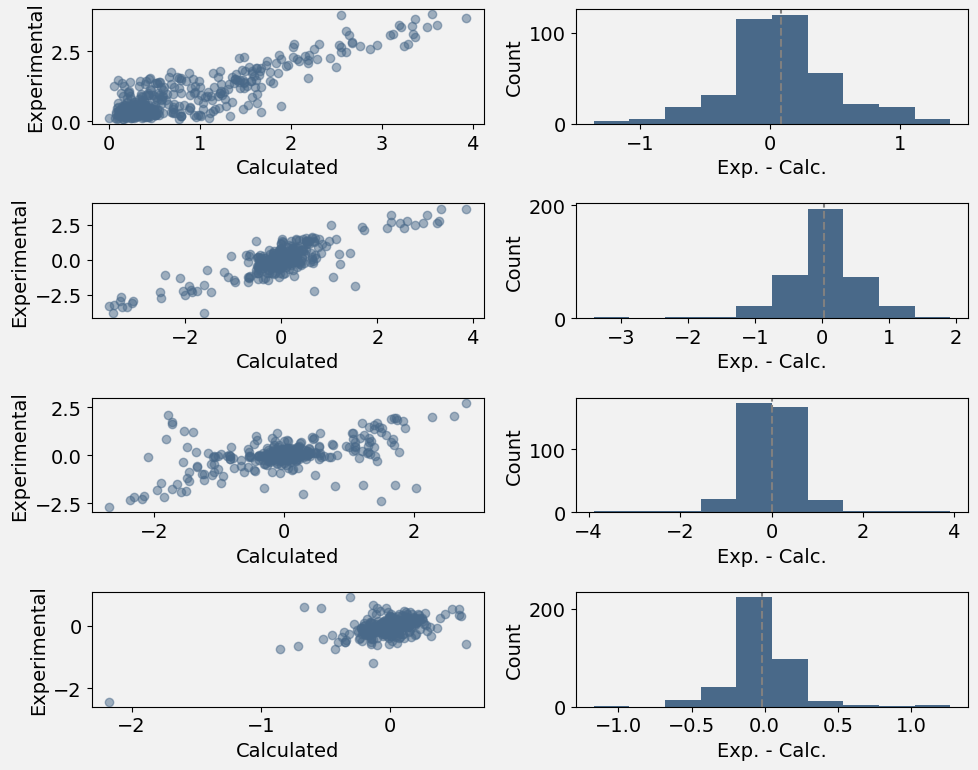

In [30]:
properties = [
    "total out of plane (exp)",
    "saddling non planarity",
    "ruffling non planarity",
    "doming non planarity",
]
fig, axes = plt.subplots(nrows=len(properties), ncols=2, figsize=(10, (2 * len(properties))))
for i, prop in enumerate(properties):
    df = fetch_geo_data(prop, "A")
    comparision_plot(df, title=prop, axs=axes[i, :])
plt.tight_layout()

/tmp/ipykernel_25777/1334211943.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: abs(x) if type(x) is not str else x)
/tmp/ipykernel_25777/1334211943.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: abs(x) if type(x) is not str else x)
/tmp/ipykernel_25777/1334211943.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: abs(x) if type(x) is not str else x)


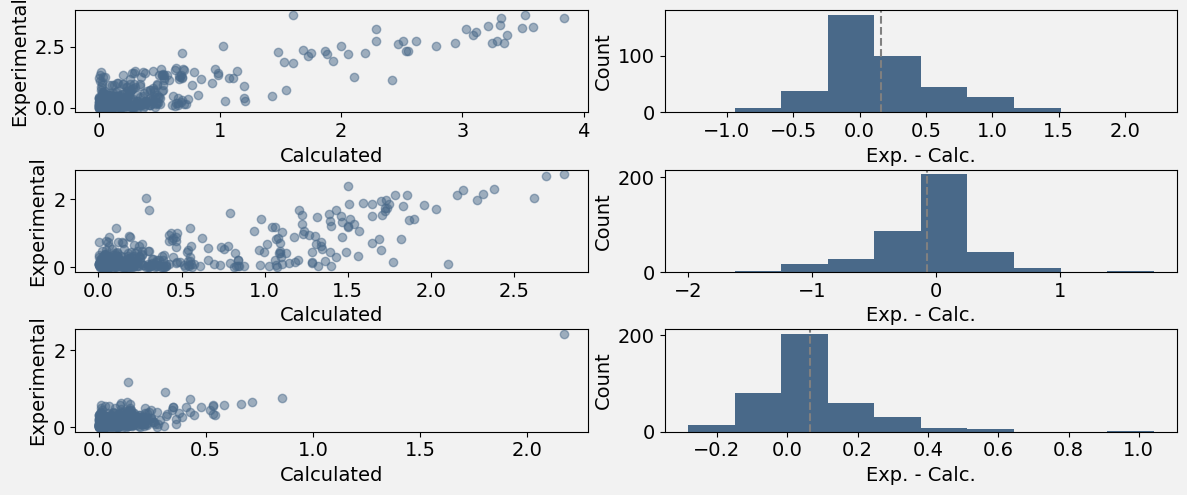

In [8]:
modes = ["saddling non planarity", "ruffling non planarity", "doming non planarity"]
fig, all_axs = plt.subplots(nrows=len(modes), ncols=2, figsize=(12, 5))
plt.tight_layout()
for i, mode in enumerate(modes):
    df = fetch_geo_data(mode, "A")
    df = df.applymap(lambda x: abs(x) if type(x) is not str else x)
    comparision_plot(df, axs=all_axs[i, :])

/tmp/ipykernel_27680/748003232.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: abs(x) if type(x) is not str else x)


    structure       property       dft   crystal
0      ADIQAI  pyrrole1 homa  0.713516  0.643957
1      AKOTUQ  pyrrole1 homa  0.690154  0.607980
2      ANUYOY  pyrrole1 homa  0.681885  0.641848
3      APANUC  pyrrole1 homa  0.657064  0.619834
4      AQOYAI  pyrrole1 homa  0.675345  0.652370
..        ...            ...       ...       ...
392    ZONQOI  pyrrole1 homa  0.704529  0.549060
393    ZONXEF  pyrrole1 homa  0.681175  0.637036
394    ZOXQUA  pyrrole1 homa  0.697477  0.651635
395    ZUTQEK  pyrrole1 homa  0.576379  0.481365
396    ZUZPIV  pyrrole1 homa  0.728958  0.629937

[397 rows x 4 columns]


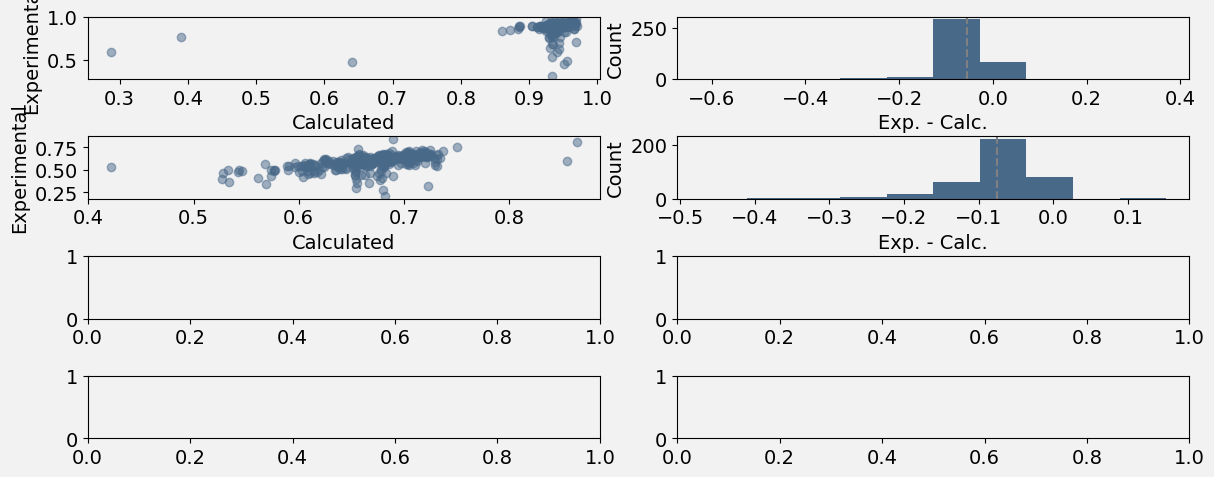

In [41]:
modes = ["pyrrole1 homa", "pyrrole2 homa", "pyrrole3 homa", "pyrrole4 homa"]
fig, all_axs = plt.subplots(nrows=len(modes), ncols=2, figsize=(12, 5))
plt.tight_layout()
df = fetch_geo_data("inner_circuit homa", None, "homa/")
df = df.applymap(lambda x: abs(x) if type(x) is not str else x)
comparision_plot(df, axs=all_axs[0, :])
df = fetch_geo_data(modes[0], None, "homa/")
for mode in modes[1:]:
    df[["dft", "crystal"]] += fetch_geo_data(mode, None, "homa/")[["dft", "crystal"]]
df[["dft", "crystal"]] = df[["dft", "crystal"]] / len(modes)
print(df)
comparision_plot(df, axs=all_axs[1, :])

# Electronic Structure

In [34]:
sids = get_sids(session, have_electronic_structure=True)

In [35]:
singlet = orca_properties_df(session, sids, "parser/S1")
triplet = orca_properties_df(session, sids, "parser/S3")
quintet = orca_properties_df(session, sids, "parser/S5")
# df = complex_details_df(session, sids)
df = pd.DataFrame(index=sids)
df["singlet_energy"] = singlet["final_energy"]
df["triplet_energy"] = triplet["final_energy"]
df["quintet_energy"] = quintet["final_energy"]
df = df.dropna()
df["spin"] = df[["singlet_energy", "triplet_energy", "quintet_energy"]].rename(columns={c: c.split("_")[0] for c in df.columns}).idxmin(axis=1)
df["spin_shift"] = df[["singlet_energy", "triplet_energy", "quintet_energy"]].apply(lambda row: np.partition(row.values, 1)[1] - np.min(row.values), axis=1) * 27.2
# add metal properties
df = pd.merge(df, complex_details_df(session, sids), left_index=True, right_index=True)
df["d_population"] = df["d_population"].astype(float)

In [36]:
df

,singlet_energy,triplet_energy,quintet_energy,spin,spin_shift,metal,metal_idx,coordination,d_population
QUWTEJ,-4256.852939,-4256.823509,-4256.764557,singlet,0.800503,Fe,19,4,6.0
AWIQEC,-2656.701304,-2656.628928,-2656.555215,singlet,1.968645,Pt,61,6,8.0
NUMSOF,-3300.140619,-3300.079171,-3300.055351,singlet,1.671380,Ni,58,6,8.0
IQOZET01,-4674.586217,-4674.640372,-4674.589977,triplet,1.370732,Ru,23,4,4.0
CEBMAZ,-4451.288092,-4451.224981,-4451.157323,singlet,1.716622,Zn,72,6,10.0
...,...,...,...,...,...,...,...,...,...
GISJAT,-3288.503052,-3288.518888,-3288.450372,triplet,0.430757,Mn,37,5,4.0
GOBWAV,-3957.912766,-3957.855987,-3957.834923,singlet,1.544374,Ni,0,6,8.0
LODSAY,-4165.320226,-4165.261745,-4165.193023,singlet,1.590671,Zn,84,5,10.0
ICIBOM,-3794.219185,-3794.153942,-3794.080392,singlet,1.774609,Ru,31,4,6.0


353
spin
singlet    312
quintet     25
triplet     16
Name: count, dtype: int64


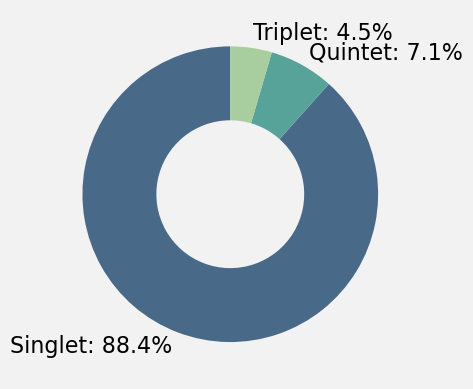

In [37]:
# Count the occurrences of each spin state
print(len(df))
spin_counts = df["spin"].value_counts()
print(spin_counts)

# Create a pie chart
labels = [f"{label.title()}: {percentage:.1f}%" for label, percentage in zip(spin_counts.index, spin_counts / spin_counts.sum() * 100)];
plt.pie(spin_counts, labels=labels, startangle=90, wedgeprops={'width': 0.5}, textprops={'fontsize': 16});

Text(0, 0.5, 'Count')

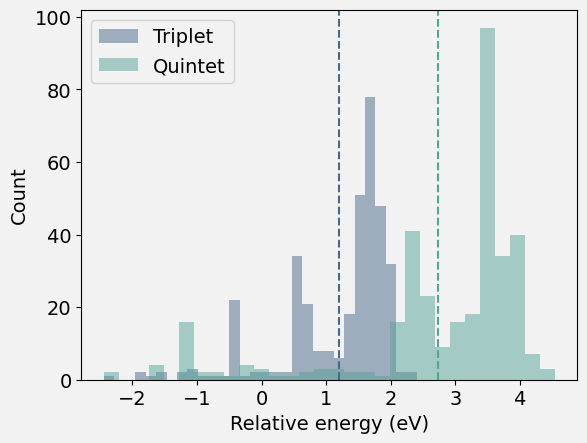

In [38]:
plt.hist((df["triplet_energy"] - df["singlet_energy"]) * 27.2, label="Triplet", alpha=0.5, bins=30, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
plt.axvline((df["triplet_energy"] - df["singlet_energy"]).mean() * 27.2, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], alpha=1, linestyle="--")
plt.hist((df["quintet_energy"] - df["singlet_energy"]) * 27.2, label="Quintet", alpha=0.5, bins=30, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.axvline((df["quintet_energy"] - df["singlet_energy"]).mean() * 27.2, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], alpha=1, linestyle="--")
plt.legend()
plt.xlabel("Relative energy (eV)")
plt.ylabel("Count")

In [39]:
def make_violin_plot(df: pd.DataFrame, group_by: str, th: int):
    # Extract unique metals
    if th is not None:
        metals = [m for m in df[group_by].unique() if len(df[df[group_by] == m]) > th]
    else:
        metals = df[group_by].unique()
    metals = sorted(metals)
    # Prepare data for plotting
    data_triplet = [(df[df[group_by] == metal]["triplet_energy"] - df[df[group_by] == metal]["singlet_energy"]) * 27.2 for metal in metals]
    data_quintet = [(df[df[group_by] == metal]["quintet_energy"] - df[df[group_by] == metal]["singlet_energy"]) * 27.2 for metal in metals]

    # Create the violin plot
    plt.figure()
    positions = range(len(metals))

    # Plot singlet, triplet, and quintet energies
    plt.violinplot(data_triplet, positions=positions, showmeans=True, widths=0.8, showextrema=False)
    plt.violinplot(data_quintet, positions=positions, showmeans=True, widths=0.8, showextrema=False)

    # Customize the plot
    plt.xticks(positions, metals)
    plt.ylabel("Relative Energy (eV)")
    plt.xlabel(group_by)

def make_bar_plot(df: pd.DataFrame, group_by: str, th: int):
    # Extract unique metals
    if th is not None:
        metals = [m for m in df[group_by].unique() if len(df[df[group_by] == m]) > th]
    else:
        metals = df[group_by].unique()
    metals = sorted(metals)
    # Count spin states for each metal
    spin_counts = {
        metal: df[df[group_by] == metal]["spin"].value_counts()
        for metal in metals
    }

    # Prepare data for plotting
    spin_states = df["spin"].unique()
    counts = {
        spin: [spin_counts[metal].get(spin, 0) for metal in metals]
        for spin in spin_states
    }

    # Create the stacked bar plot
    positions = range(len(metals))
    bottom = np.zeros(len(metals))
    plt.figure()

    for spin in spin_states:
        plt.bar(positions, counts[spin], bottom=bottom, label=spin)
        bottom += counts[spin]

    # Customize the plot
    plt.xticks(positions, metals)
    plt.ylabel("Count")
    plt.xlabel(group_by)
    plt.legend()

In [40]:
df

,singlet_energy,triplet_energy,quintet_energy,spin,spin_shift,metal,metal_idx,coordination,d_population
QUWTEJ,-4256.852939,-4256.823509,-4256.764557,singlet,0.800503,Fe,19,4,6.0
AWIQEC,-2656.701304,-2656.628928,-2656.555215,singlet,1.968645,Pt,61,6,8.0
NUMSOF,-3300.140619,-3300.079171,-3300.055351,singlet,1.671380,Ni,58,6,8.0
IQOZET01,-4674.586217,-4674.640372,-4674.589977,triplet,1.370732,Ru,23,4,4.0
CEBMAZ,-4451.288092,-4451.224981,-4451.157323,singlet,1.716622,Zn,72,6,10.0
...,...,...,...,...,...,...,...,...,...
GISJAT,-3288.503052,-3288.518888,-3288.450372,triplet,0.430757,Mn,37,5,4.0
GOBWAV,-3957.912766,-3957.855987,-3957.834923,singlet,1.544374,Ni,0,6,8.0
LODSAY,-4165.320226,-4165.261745,-4165.193023,singlet,1.590671,Zn,84,5,10.0
ICIBOM,-3794.219185,-3794.153942,-3794.080392,singlet,1.774609,Ru,31,4,6.0


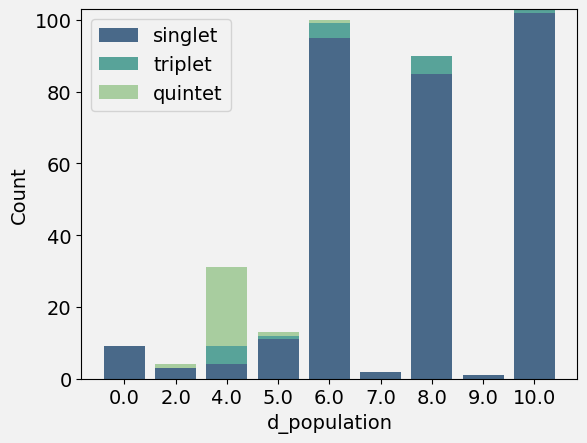

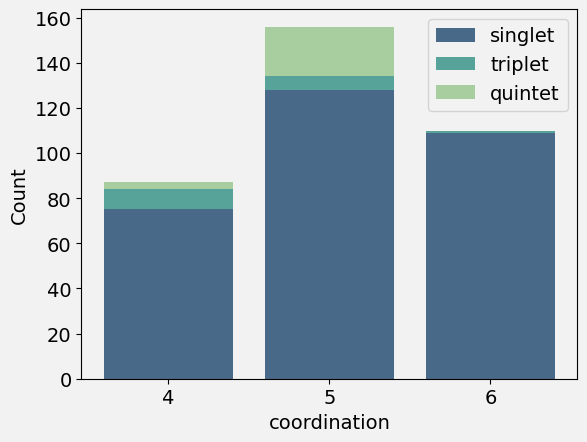

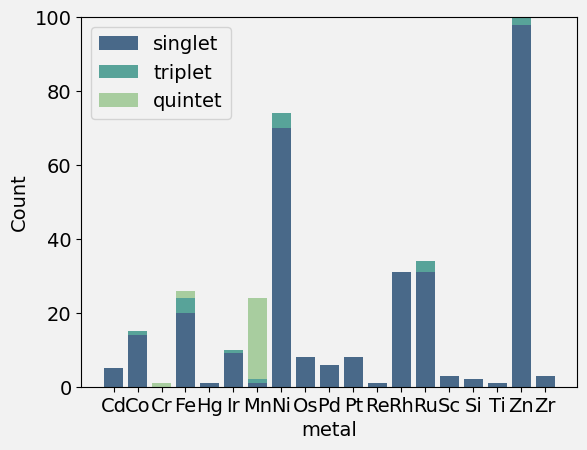

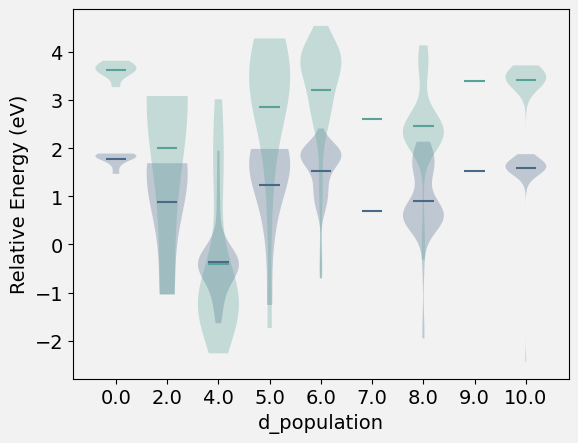

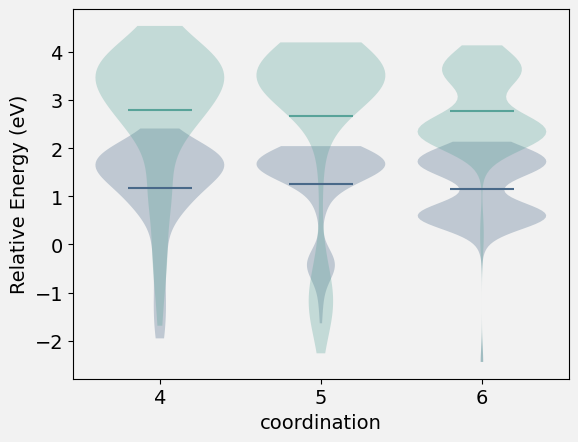

In [41]:
make_bar_plot(df, "d_population", th=0)
make_bar_plot(df, "coordination", th=0)
make_bar_plot(df, "metal", th=0)
make_violin_plot(df, "d_population", th=0)
make_violin_plot(df, "coordination", th=0)

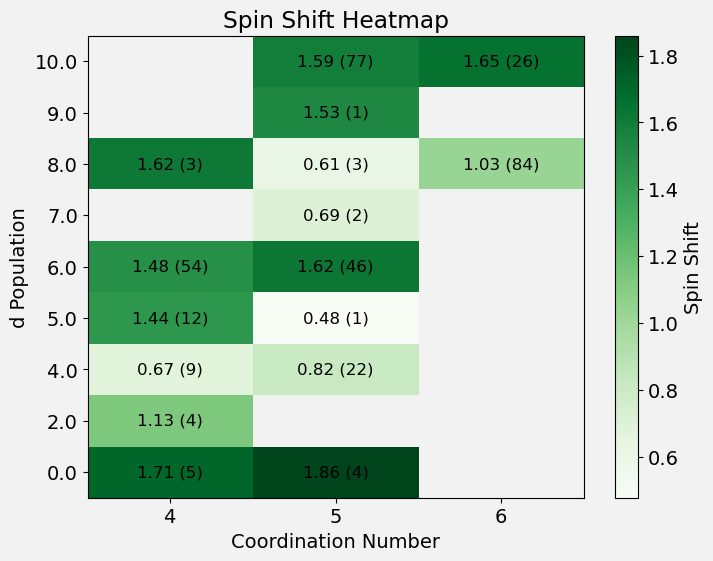

In [46]:
# Prepare data for heatmap
pivot = df.pivot_table(index="d_population", columns="coordination", values="spin_shift", aggfunc="mean")
count_pivot = df.pivot_table(index="d_population", columns="coordination", values="spin_shift", aggfunc="count")
plt.figure(figsize=(8, 6))
im = plt.imshow(pivot, aspect="auto", cmap="Greens", origin="lower")
plt.colorbar(im, label="Spin Shift")
plt.xlabel("Coordination Number")
plt.ylabel("d Population")
plt.xticks(ticks=range(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)
plt.title("Spin Shift Heatmap")
# Annotate each cell with its value and count
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        count = int(count_pivot.iloc[i, j]) if not np.isnan(count_pivot.iloc[i, j]) else 0
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f} ({count})", ha="center", va="center", color="black", fontsize=12)

compare electronic structure between high-level singlet and base level

Text(0, 0.5, 'count')

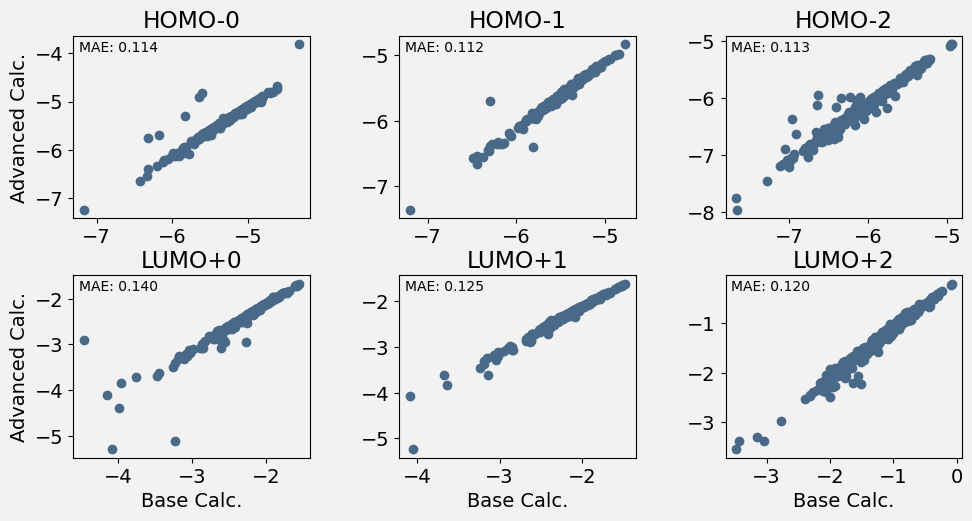

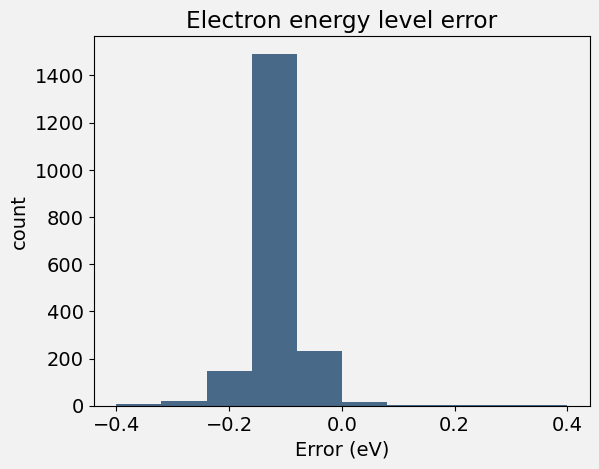

In [61]:
base_calc = orca_properties_df(session, sids, "parser/base_calculation")
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))
errors = []
plt.tight_layout()
cols = ["HOMO-", "LUMO+"]
for i in range(2):
    for j in range(3):
        col = "{}{}_energy".format(cols[i], j)
        base_vals = base_calc.loc[singlet.index, col]
        axs[i, j].scatter(base_vals, singlet[col])
        axs[i, j].set_title(col.split("_")[0])
        errors += list(singlet[col] - base_vals)
        mae = np.mean(np.abs(singlet[col] - base_vals))
        axs[i, j].text(0.025, 0.975, f"MAE: {mae:.3f}", transform=axs[i, j].transAxes, fontsize=10, verticalalignment='top')
        if i == 1:
            axs[i, j].set_xlabel("Base Calc.")
        if j == 0:
            axs[i, j].set_ylabel("Advanced Calc.")
plt.figure()
plt.hist(errors, range=(-0.4, 0.4))
plt.title("Electron energy level error")
plt.xlabel("Error (eV)")
plt.ylabel("count")

Text(0.5, 1.0, 'HOMO-LUMO Gap')

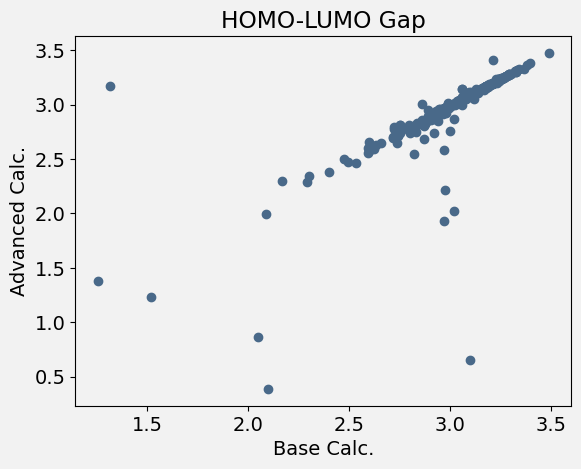

In [62]:
base_homo_lumo = base_calc.loc[singlet.index, "LUMO+0_energy"] - base_calc.loc[singlet.index, "HOMO-0_energy"]
singlet_homo_lumo = singlet["LUMO+0_energy"] - singlet["HOMO-0_energy"]
plt.scatter(base_homo_lumo, singlet_homo_lumo)
plt.xlabel("Base Calc.")
plt.ylabel("Advanced Calc.")
plt.title("HOMO-LUMO Gap")

analyze the proeprties more generally


In [63]:
# enhance the dataframe with orbital level energies according to the spin-state
spin_state_data = {"singlet": singlet, "triplet": triplet, "quintet": quintet}
for col in singlet.columns:
    if not col == "final_energy":
        df[col] = [spin_state_data[df.loc[struct, "spin"]].loc[struct, col] for struct in df.index]
for spin in spin_state_data.keys():
    df["relative_" + spin] = [(df.loc[struct, spin + "_energy"] - spin_state_data[df.loc[struct, "spin"]].loc[struct, "final_energy"]) * 27.2 + df.loc[struct, "HOMO-0_energy"] for struct in df.index]

Text(0, 0.5, 'Energy (eV)')

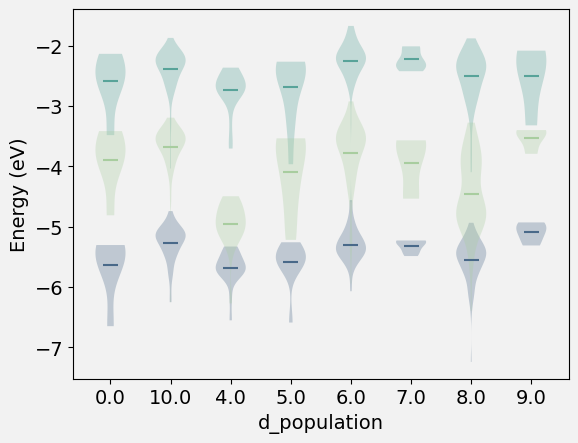

In [64]:
column = "d_population"
df["next_spin"] = [np.partition(vec, 1)[1] for vec in df[["relative_singlet", "relative_triplet", "relative_quintet"]].values]
df["next_next_spin"] = [np.partition(vec, 1)[2] for vec in df[["relative_singlet", "relative_triplet", "relative_quintet"]].values]
metals = sorted([m for m in df[column].unique() if len(df[df[column] == m]) > 2])
positions = [1 * i for i in range(len(metals))]
plt.violinplot([df[df[column] == m]["HOMO-0_energy"].values.tolist() for m in metals], positions=positions, showextrema=False, showmeans=True);
plt.violinplot([df[df[column] == m]["LUMO+0_energy"].values.tolist() for m in metals], positions=positions, showextrema=False, showmeans=True);
plt.violinplot([df[df[column] == m]["next_spin"].values.tolist() for m in metals], positions=positions, showextrema=False, showmeans=True);
# plt.violinplot([df[df[column] == m]["next_next_spin"].values.tolist() for m in metals], positions=positions, showextrema=False, showmeans=True);

plt.xticks(positions, metals, rotation=0);
plt.xlabel(column)
plt.ylabel("Energy (eV)")

In [79]:
np_df = non_planarity_df(session, sids, "A", add_total_non_planarity=True)
homa_df = homa_values_df(session, sids, "homa", True)
df = df.merge(np_df, left_index=True, right_index=True).merge(homa_df, left_index=True, right_index=True)

In [80]:
df

,metal,coordination,d_population,singlet_energy,triplet_energy,quintet_energy,spin,HOMO-0_energy,LUMO+0_energy,HOMO-LUMO_gap,...,wavingx2 non planarity,propellering2 non planarity,total out of plane (exp),pyrrole1,pyrrole2,pyrrole3,pyrrole4,inner_circuit,outer_circuit,pyrrole_avg
IWOHEI,Zn,5,10.0,-8802.119609,-8802.061172,-8801.992632,singlet,-5.1258,-2.2098,2.9160,...,-0.012208,0.001262,0.218228,0.646326,0.697808,0.646534,0.635605,0.933003,0.624674,0.656569
YESKOZ,Zn,5,10.0,-4349.874546,-4349.812540,-4349.744571,singlet,-5.1633,-2.0939,3.0694,...,0.011373,0.001426,0.090532,0.639272,0.712869,0.639007,0.653601,0.953068,0.640260,0.661187
TOJYID,Ru,4,6.0,-2958.957242,-2958.894385,-2958.820453,singlet,-5.0155,-2.4197,2.5958,...,-0.064406,-0.009314,0.416951,0.639178,0.694679,0.629426,0.652964,0.942902,0.632664,0.654062
HALXIB,Cd,5,10.0,-2364.315269,-2364.259195,-2364.190851,singlet,-4.9919,-2.1450,2.8469,...,0.097913,0.010099,0.428647,0.606073,0.682278,0.593759,0.613832,0.885888,0.531924,0.623985
UQIFEI,Ni,6,8.0,-3615.379426,-3615.356642,-3615.288399,singlet,-5.1921,-2.0426,3.1495,...,-0.009573,-0.000543,1.482263,0.630711,0.711735,0.651258,0.618578,0.944889,0.653066,0.653071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZOHQUK,Ni,6,8.0,-3724.888487,-3724.866470,-3724.800703,singlet,-5.5026,-2.4129,3.0897,...,0.024371,0.001474,1.430705,0.706639,0.744250,0.691559,0.707363,0.940305,0.732005,0.712453
UVUCIY,Rh,4,6.0,-2958.702840,-2958.638399,-2958.566825,singlet,-5.3066,-2.2355,3.0711,...,-0.000847,0.000304,0.630087,0.667617,0.727092,0.667491,0.667712,0.951457,0.675550,0.682478
GISJEX,Mn,5,4.0,-3551.067868,-3551.082650,-3551.108361,quintet,-5.8127,-2.7941,3.0186,...,-0.035366,-0.004178,0.433960,0.705416,0.760187,0.706384,0.704816,0.931342,0.747430,0.719201
VAFQEY,Ni,6,8.0,-2730.466370,-2730.441540,-2730.375406,singlet,-5.4658,-2.2345,3.2313,...,0.004932,0.000118,1.614473,0.687976,0.744675,0.688757,0.688931,0.937994,0.713660,0.702585


Text(0, 0.5, 'Absolute Ruffling (A)')

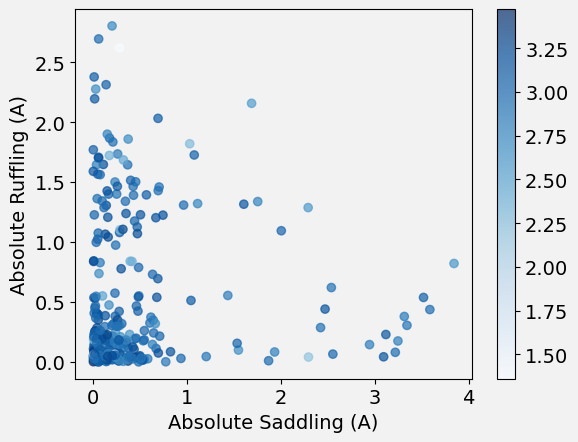

In [81]:
plt.scatter(df["saddling non planarity"].abs(), df["ruffling non planarity"].abs(), c=df["HOMO-LUMO_gap"], cmap="Blues", alpha=0.7)
plt.colorbar()
plt.xlabel("Absolute Saddling (A)")
plt.ylabel("Absolute Ruffling (A)")

a= -0.06402514060126871 b= -5.358304497999547
a= -0.12208789145518587 b= -2.3316452129547875
a= -0.34827979359624023 b= -3.756474502561304
a= -0.0580627508539182 b= 3.026659285044759
a= -0.2842546529949715 b= 1.6018299954382427
a= -0.028938043907594448 b= -5.396291719342643
a= -0.08756721070394372 b= -2.387494282827539
a= -0.40897233178713255 b= -3.8342699259544397
a= 0.0008061943178640936 b= 2.9787480324106355
a= -0.0346101207608602 b= 1.3682363916056033
a= -0.07717233718267745 b= -5.3768624234200875
a= -0.11815564012530025 b= -2.3799048116541823
a= -0.23991660280600433 b= -3.937260277856858
a= -0.02972547040037057 b= 2.9775655995201675
a= -0.03964543658296791 b= 1.3657681614243653


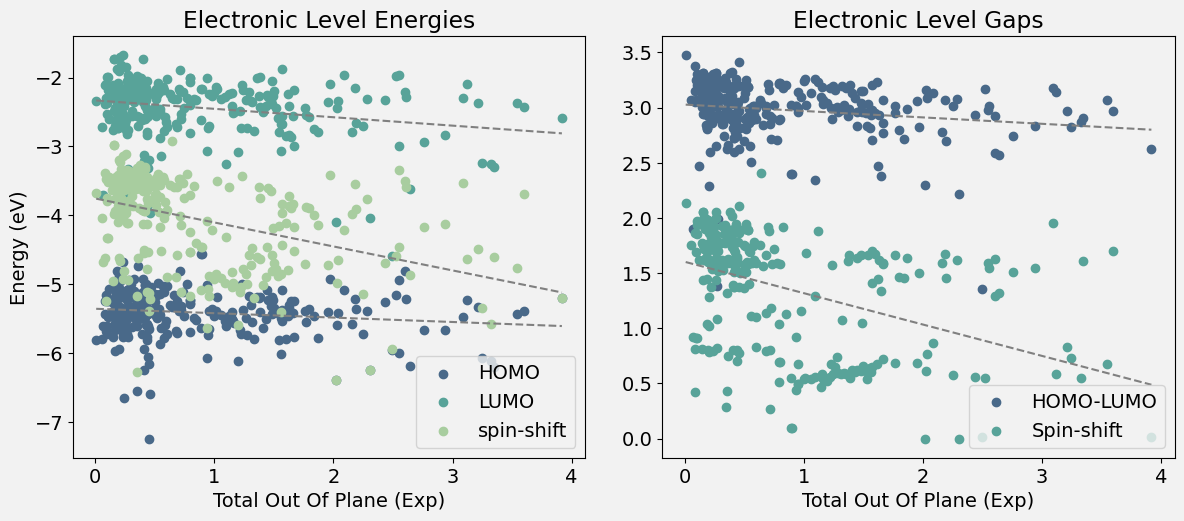

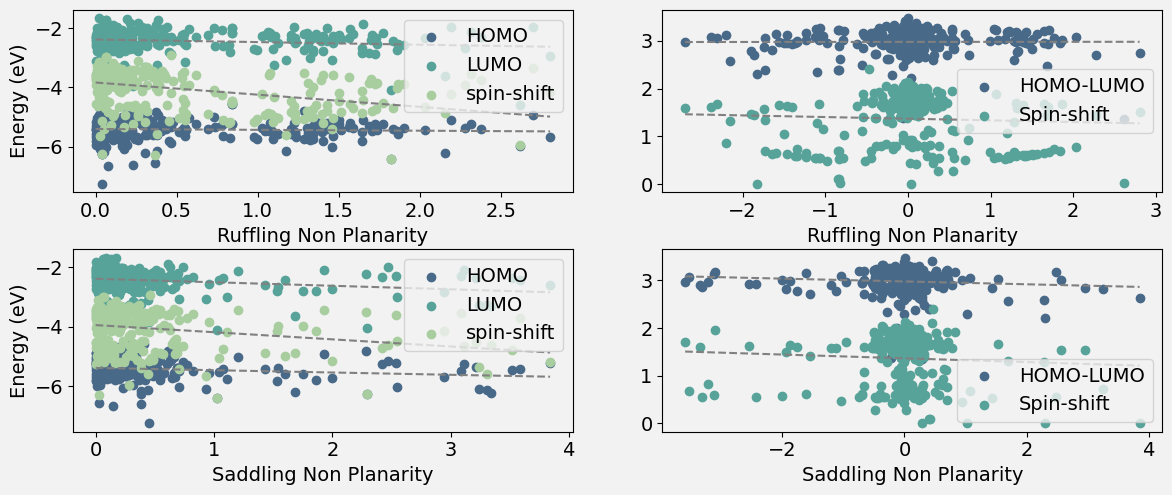

In [82]:
def non_planarity_vs_levels(props):
    fig, axs = plt.subplots(nrows=len(props), ncols=2, figsize=(12, 5))
    plt.tight_layout()
    for i, prop in enumerate(props):
        if len(props) == 1:
            ax_row = axs
        else:
            ax_row = axs[i, :]
        scatter_plot(df[prop].abs(), df["HOMO-0_energy"], ax=ax_row[0], label="HOMO", add_fitted_line=True, linecolor="gray")
        scatter_plot(df[prop].abs(), df["LUMO+0_energy"], ax=ax_row[0], label="LUMO", add_fitted_line=True, linecolor="gray")
        scatter_plot(df[prop].abs(), df["next_spin"], ax=ax_row[0], label="spin-shift", add_fitted_line=True, linecolor="gray")
        ax_row[0].set_ylabel("Energy (eV)")
        ax_row[0].legend()
        scatter_plot(df[prop], df["HOMO-LUMO_gap"], ax=ax_row[1], label="HOMO-LUMO", add_fitted_line=True, linecolor="gray")
        scatter_plot(df[prop], df["next_spin"] - df["HOMO-0_energy"], label="Spin-shift", ax=ax_row[1], add_fitted_line=True, linecolor="gray")
        ax_row[1].legend()
        if len(props) == 1:
            ax_row[1].set_title("Electronic Level Gaps")
            ax_row[0].set_title("Electronic Level Energies")
        ax_row[1].set_xlabel(prop.split("_")[0].title())
        ax_row[0].set_xlabel(prop.split("_")[0].title())

non_planarity_vs_levels(["total out of plane (exp)_y"])
non_planarity_vs_levels(["ruffling non planarity_y", "saddling non planarity_y"])
# plt.legend()

a= 0.6628071178452397 b= -6.0315500860100615
a= 3.5059871725704306 b= -5.714209194656247
a= 2.6789876696324066 b= -6.5514724789649765
a= 2.8431800547251926 b= 0.31734089135381416
a= 2.0161805517871696 b= -0.5199223929549157
a= -2.246444251563337 b= -3.9029465916412995
a= -2.9351525066388153 b= -0.4618090631597007
a= -5.754582770215032 b= -0.18035989658012724
a= -0.6887082550754778 b= 3.441137528481598
a= -3.5081385186516925 b= 3.7225866950611692


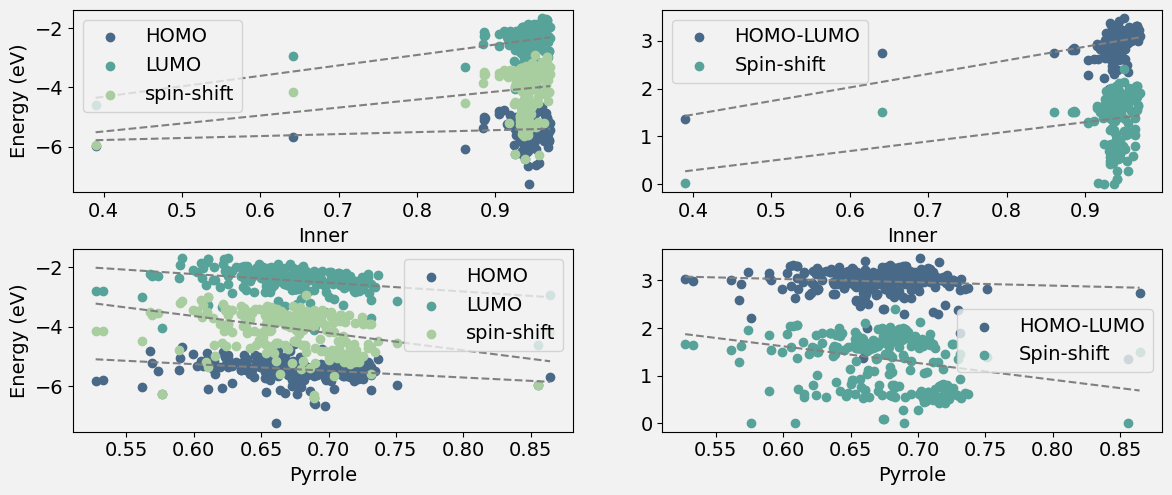

In [83]:
non_planarity_vs_levels(["inner_circuit", "pyrrole_avg"])

In [ ]:
scatter_plot(df["Pyrrole HOMA"].astype(float), df["HOMO"].astype(float), label="HOMO", add_fitted_line=True, linecolor="gray")
scatter_plot(df["Pyrrole HOMA"].astype(float), df["LUMO"].astype(float), label="LUMO", add_fitted_line=True, linecolor="gray")
plt.xlabel("Pyrrole HOMA")
plt.ylabel("Energy (eV)")

# NMR

## Sheilding

In [43]:
import pandas as pd
# fetch all rows matching the filter and convert to DataFrame
rows = session.query(StructureProperty).filter(StructureProperty.source.like("%shielding%")).all()
raw_nmr = pd.DataFrame([r.__dict__ for r in rows]).drop('_sa_instance_state', axis=1)
raw_nmr["atom"] = list(map(lambda p: p.split("/")[0], raw_nmr["property"]))
raw_nmr["type"] = list(map(lambda p: p.split("/")[1], raw_nmr["property"]))
# set unique index
raw_nmr["index"] = list(map(lambda x: "_".join(x), raw_nmr[["structure", "atom"]].values))
raw_nmr = raw_nmr.set_index("index")
# filter only "isotropic" shifts - these are the "NMR" values
raw_nmr = raw_nmr[raw_nmr["type"] == "isotropic"]
# take only relevant columns
raw_nmr = raw_nmr[["structure", "atom", "value"]]

In [44]:
# hydrogen substituent ID = 1
rows = session.query(StructureSubstituents).filter(StructureSubstituents.substituent == 1).all()
hydrogens = pd.DataFrame([r.__dict__ for r in rows]).drop('_sa_instance_state', axis=1)
# setup index like the nmr df - IMPORTANT: the atom indexing is different between the tables!!! note the very important -1.
hydrogens["index"] = list(map(lambda x: f"{x[0]}_H{int(x[1].split(',')[0]) - 1}", hydrogens[["structure", "atom_indicis"]].values))
hydrogens = hydrogens.set_index("index")
hydrogens = hydrogens[["position", "position_index"]]
# join with NMR data
hydrogens = pd.merge(hydrogens, raw_nmr, how="inner", left_index=True, right_index=True)
# rescale value to "proper" NMR value (should use shift of TMS)
hydrogens["value"] = - hydrogens["value"]

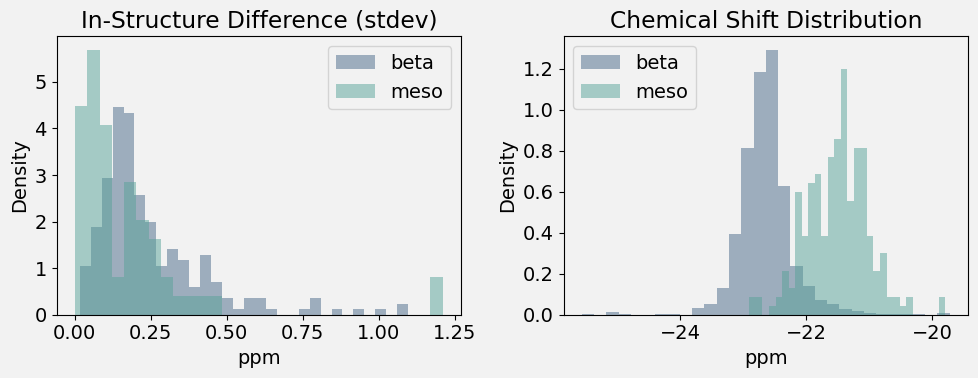

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 1. Histogram of std of beta hydrogens per structure
ajr_beta = hydrogens[hydrogens["position"] == "beta"][["structure", "value"]].groupby(by="structure").std()
axs[0].hist(ajr_beta["value"].dropna(), bins=30, alpha=0.5, density=True, label="beta")
ajr_meso = hydrogens[hydrogens["position"] == "meso"][["structure", "value"]].groupby(by="structure").std()
axs[0].hist(ajr_meso["value"].dropna(), bins=30, alpha=0.5, density=True, label="meso")
axs[0].set_title("In-Structure Difference (stdev)")
axs[0].set_xlabel("ppm")
axs[0].set_ylabel("Density")
axs[0].legend()

# 2. Histogram of std of meso hydrogens per structure

# 3. Distribution of all beta and meso hydrogen shifts
axs[1].hist(hydrogens[hydrogens["position"] == "beta"]["value"], density=True, alpha=0.5, label="beta", bins=30)
axs[1].hist(hydrogens[hydrogens["position"] == "meso"]["value"], density=True, alpha=0.5, label="meso", bins=30)
axs[1].set_title("Chemical Shift Distribution")
axs[1].set_xlabel("ppm")
axs[1].set_ylabel("Density")
axs[1].legend()

plt.tight_layout()

In [46]:
metals = complex_details_df(session, raw_nmr["structure"].unique())
metals["structure"] = metals.index
metals["index"] = list(map(lambda x: f"{x[0]}_{x[1]}{int(x[2])}", metals[["structure", "metal", "metal_idx"]].values))
metals = metals.set_index("index")
metals = pd.merge(metals, raw_nmr, how="inner", left_index=True, right_index=True)
metals["value"] = - metals["value"]
metals = metals[["metal", "coordination", "d_population", "value"]]

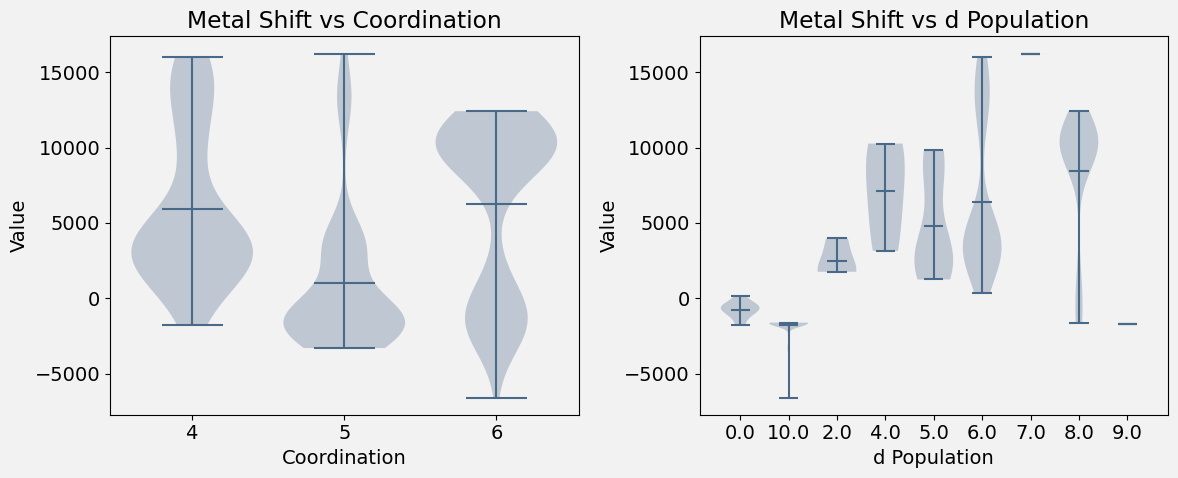

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Violin plot for "coordination"
coord_groups = metals.groupby("coordination")["value"].apply(list)
axs[0].violinplot(coord_groups.values, positions=range(len(coord_groups)), showmeans=True, widths=0.8)
axs[0].set_xticks(range(len(coord_groups)))
axs[0].set_xticklabels(coord_groups.index)
axs[0].set_xlabel("Coordination")
axs[0].set_ylabel("Value")
axs[0].set_title("Metal Shift vs Coordination")

# Violin plot for "d_population"
dpop_groups = metals.groupby("d_population")["value"].apply(list)
axs[1].violinplot(dpop_groups.values, positions=range(len(dpop_groups)), showmeans=True, widths=0.8)
axs[1].set_xticks(range(len(dpop_groups)))
axs[1].set_xticklabels(dpop_groups.index)
axs[1].set_xlabel("d Population")
axs[1].set_ylabel("Value")
axs[1].set_title("Metal Shift vs d Population")

plt.tight_layout()

## NICS

In [48]:
rows = session.query(StructureProperty).filter(StructureProperty.source.like("%nics%")).all()
raw_nics = pd.DataFrame([r.__dict__ for r in rows]).drop('_sa_instance_state', axis=1)
# fabulize dataframe
raw_nics["pyrrole"] = [int(x.split("/")[0][-1]) for x in raw_nics["property"]]
raw_nics["z"] = [float(x.split("/")[1][1:]) for x in raw_nics["property"]]
raw_nics["type"] = [x.split("/")[-1] for x in raw_nics["property"]]
raw_nics["value"] = - raw_nics["value"] # to obey the convention of NICS notation
raw_nics = raw_nics[["structure", "pyrrole", "z", "type", "value"]]
raw_nics = raw_nics[raw_nics["type"] != "anisotropic"]

In [49]:
# pyrrole_nics = raw_nics[(raw_nics["type"] == "zz")].groupby(by=["pyrrole", "structure"]).min()
pyrrole_nics = raw_nics[(raw_nics["type"] == "zz") & (raw_nics["z"].abs() == 1)].groupby(by=["pyrrole", "structure"]).min()
pyrrole_nics = pyrrole_nics.reset_index()
avg_nics = pyrrole_nics[["structure", "value"]].groupby(by="structure").mean()
pyrrole_nics = pd.merge(pyrrole_nics, avg_nics, how="left", on="structure")
pyrrole_nics = pyrrole_nics.rename(columns={"value_x": "pyrrole_nics", "value_y": "avg_nics"})
pyrrole_nics.index = [f"{sid}_{pyrrole}" for sid, pyrrole in pyrrole_nics[["structure", "pyrrole"]].values]
pyrrole_nics

,pyrrole,structure,z,type,pyrrole_nics,avg_nics
AKOTUQ_1,1,AKOTUQ,-1.0,zz,-20.015148,-21.237695
APANUC_1,1,APANUC,-1.0,zz,-21.420610,-21.304775
ARODOC_1,1,ARODOC,-1.0,zz,-19.418469,-18.607371
ATEWUT_1,1,ATEWUT,-1.0,zz,-17.661467,-17.728441
ATUSOX_1,1,ATUSOX,-1.0,zz,-21.819897,-21.649242
...,...,...,...,...,...,...
ZITNIZ_4,4,ZITNIZ,-1.0,zz,-22.707912,-22.202985
ZOHQOE_4,4,ZOHQOE,-1.0,zz,-24.412805,-24.417631
ZOHQUK_4,4,ZOHQUK,-1.0,zz,-23.085898,-23.104874
ZOXQUA_4,4,ZOXQUA,-1.0,zz,-18.793000,-17.157646


In [56]:
beta_to_pyrrole = {
    1: 1,
    2: 1,
    3: 2,
    4: 2,
    5: 3,
    6: 3,
    7: 4,
    8: 4
}

hydrogens["pyrrole"] = list(map(lambda x: str(int(beta_to_pyrrole[x[1]])) if x[0] == "beta" else None, hydrogens[["position", "position_index"]].values))
ajr = hydrogens[hydrogens["position"] == "beta"]
ajr.index = list(map(lambda x: "_".join(x), ajr[["structure", "pyrrole"]].values))
ajr = pd.merge(pyrrole_nics, ajr, right_index=True, left_index=True)
ajr = ajr.rename(columns={"value": "shift", "structure_x": "structure", "pyrrole_x": "pyrrole"})
# add HOMA score per porphyrin
q = session.query(StructureProperty.structure, StructureProperty.property, StructureProperty.value).filter(StructureProperty.source == 'homa/dft').filter(StructureProperty.property.like("%pyrrole%")).filter(StructureProperty.property.like("%homa%"))
homa_df = pd.read_sql(q.statement, session.connection())
homa_df["pyrrole"] = [int(s.split()[0][-1]) for s in homa_df["property"]]
homa_df = homa_df.drop(columns=["property"]).set_index(["structure", "pyrrole"])
homa_df = homa_df.reset_index()
homa_df = homa_df.rename(columns={"value": "homa"})
q = session.query(StructureProperty.structure, StructureProperty.property, StructureProperty.value).filter(StructureProperty.source == 'homa/dft').filter(StructureProperty.property.like("%inner_circuit%")).filter(StructureProperty.property.like("%homa%"))
inner_homa_df = pd.read_sql(q.statement, session.connection())
inner_homa_df = inner_homa_df.drop(columns=["property"]).rename(columns={"value": "inner_homa"})

# avg_homa = homa_df[["structure", "homa"]].groupby(by="structure").mean()
# avg_homa = avg_homa.rename(columns={"homa": "avg_homa"})
homa_df = pd.merge(homa_df, inner_homa_df, how="left", on="structure")
homa_df.index = list(map(lambda x: f"{x[0]}_{x[1]}", homa_df[["structure", "pyrrole"]].values))
homa_df = homa_df[["homa", "inner_homa"]]
ajr = pd.merge(ajr, homa_df, left_index=True, right_index=True)
ajr = ajr[["structure", "pyrrole", "position_index", "pyrrole_nics", "avg_nics", "shift", "homa", "inner_homa"]]
ajr = ajr.reset_index()
ajr

,index,structure,pyrrole,position_index,pyrrole_nics,avg_nics,shift,homa,inner_homa
0,AKOTUQ_1,AKOTUQ,1,1,-20.015148,-21.237695,-22.146,0.694062,0.932656
1,AKOTUQ_2,AKOTUQ,2,4,-19.325954,-21.237695,-22.022,0.746310,0.932656
2,AKOTUQ_3,AKOTUQ,3,5,-23.127721,-21.237695,-22.160,0.658933,0.932656
3,AKOTUQ_3,AKOTUQ,3,6,-23.127721,-21.237695,-22.888,0.658933,0.932656
4,AKOTUQ_4,AKOTUQ,4,7,-22.481955,-21.237695,-22.688,0.661314,0.932656
...,...,...,...,...,...,...,...,...,...
1817,ZUZPIV_2,ZUZPIV,2,4,-26.436913,-23.575510,-22.810,0.719787,0.937502
1818,ZUZPIV_3,ZUZPIV,3,5,-21.189232,-23.575510,-22.522,0.769272,0.937502
1819,ZUZPIV_3,ZUZPIV,3,6,-21.189232,-23.575510,-22.623,0.769272,0.937502
1820,ZUZPIV_4,ZUZPIV,4,7,-21.848382,-23.575510,-23.252,0.762424,0.937502


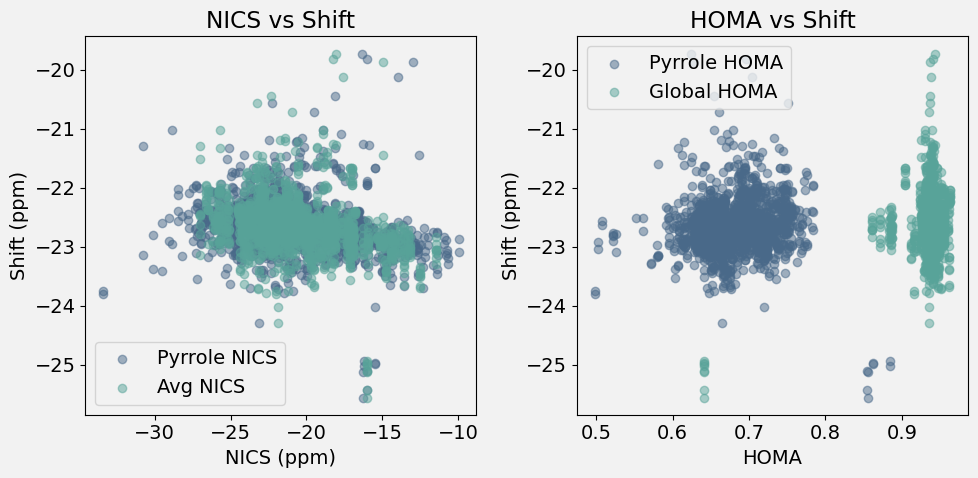

In [57]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

# Pyrrole NICS vs Shift
axs[0].scatter(ajr["pyrrole_nics"], ajr["shift"], alpha=0.5, label="Pyrrole NICS")
axs[0].scatter(ajr["avg_nics"], ajr["shift"], alpha=0.5, label="Avg NICS")
axs[0].set_xlabel("NICS (ppm)")
axs[0].set_ylabel("Shift (ppm)")
axs[0].set_title("NICS vs Shift")
axs[0].legend()

# HOMA vs Shift
axs[1].scatter(ajr["homa"], ajr["shift"], alpha=0.5, label="Pyrrole HOMA")
axs[1].scatter(ajr["inner_homa"], ajr["shift"], alpha=0.5, label="Global HOMA")
axs[1].set_xlabel("HOMA")
axs[1].set_ylabel("Shift (ppm)")
axs[1].set_title("HOMA vs Shift")
axs[1].legend()

plt.tight_layout()

In [59]:
ajr

,index,structure,pyrrole,position_index,pyrrole_nics,avg_nics,shift,homa,avg_homa
0,AKOTUQ_1,AKOTUQ,1,1,-20.015148,-21.237695,-22.146,0.694062,0.690154
1,AKOTUQ_2,AKOTUQ,2,4,-19.325954,-21.237695,-22.022,0.746310,0.690154
2,AKOTUQ_3,AKOTUQ,3,5,-23.127721,-21.237695,-22.160,0.658933,0.690154
3,AKOTUQ_3,AKOTUQ,3,6,-23.127721,-21.237695,-22.888,0.658933,0.690154
4,AKOTUQ_4,AKOTUQ,4,7,-22.481955,-21.237695,-22.688,0.661314,0.690154
...,...,...,...,...,...,...,...,...,...
1817,ZUZPIV_2,ZUZPIV,2,4,-26.436913,-23.575510,-22.810,0.719787,0.728958
1818,ZUZPIV_3,ZUZPIV,3,5,-21.189232,-23.575510,-22.522,0.769272,0.728958
1819,ZUZPIV_3,ZUZPIV,3,6,-21.189232,-23.575510,-22.623,0.769272,0.728958
1820,ZUZPIV_4,ZUZPIV,4,7,-21.848382,-23.575510,-23.252,0.762424,0.728958


In [91]:
avg_structure_df = ajr.drop(columns=["index", "pyrrole", "position_index"])
avg_structure_df = avg_structure_df.groupby("structure").mean()
avg_structure_df

feat = StructurePropertyFeaturizer(["HOMO-LUMO_gap"], property_units=[None], navalue=None, property_source="parser/S1") + \
        StructurePropertyFeaturizer(["total out of plane (exp)", "saddling non planarity", "ruffling non planarity"], property_units=["A", "A", "A"], navalue=None, property_source="porphystruct/dft")
df = feat.featurize(session, avg_structure_df.index).abs()
df.columns = ["gap", "total_np", "saddling_np", "ruffling_np"]
avg_structure_df = pd.merge(avg_structure_df, df, left_index=True, right_index=True)

In [92]:
avg_structure_df

,pyrrole_nics,avg_nics,shift,homa,avg_homa,gap,total_np,saddling_np,ruffling_np
structure,,,,,,,,,
AKOTUQ,-21.760076,-21.237695,-22.393667,0.680144,0.690154,2.9305,2.433874,2.418908,0.286852
APANUC,-21.304775,-21.304775,-22.516625,0.657064,0.657064,2.9009,0.363446,0.282347,0.145933
ARODOC,-18.607371,-18.607371,-22.742375,0.685122,0.685122,3.2163,0.512510,0.496617,0.051501
ATUSOX,-21.649242,-21.649242,-22.617125,0.655549,0.655549,2.9373,0.390836,0.317047,0.152533
AWIQEC,-14.994562,-14.994562,-22.939500,0.691123,0.691123,3.3041,0.102180,0.078359,0.013015
...,...,...,...,...,...,...,...,...,...
ZITNIZ,-22.202985,-22.202985,-22.592875,0.677969,0.677969,3.0545,0.165279,0.039264,0.002779
ZOHQOE,-24.417631,-24.417631,-22.486000,0.706982,0.706982,3.2399,0.997472,0.158442,1.042246
ZOHQUK,-23.104874,-23.104874,-22.484375,0.712453,0.712453,3.0897,1.430705,0.565318,1.393541


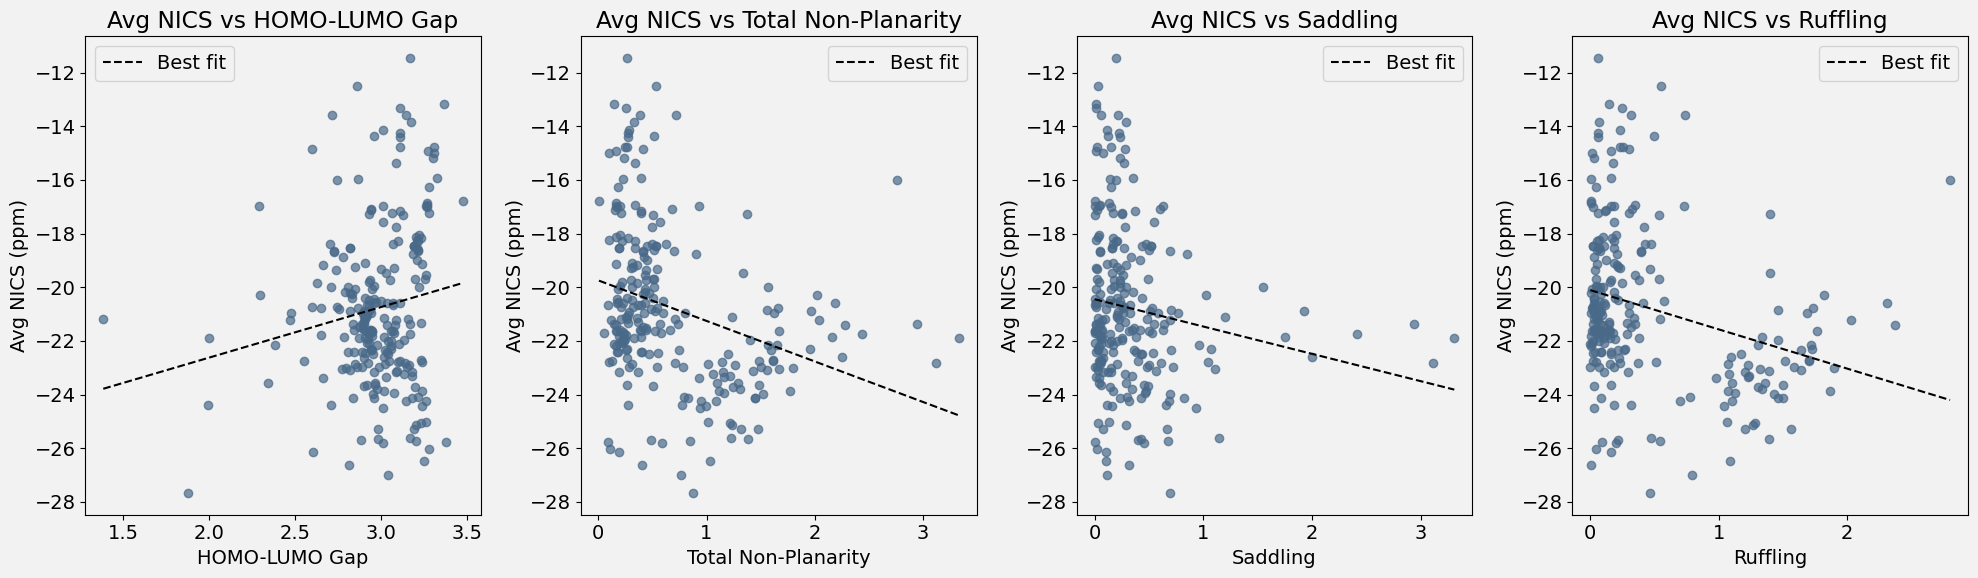

In [93]:
fig, axs = plt.subplots(ncols=4, figsize=(20, 6))
props = ["gap", "total_np", "saddling_np", "ruffling_np"]
titles = ["HOMO-LUMO Gap", "Total Non-Planarity", "Saddling", "Ruffling"]

for ax, prop, title in zip(axs.flat, props, titles):
    x = avg_structure_df[prop]
    y = avg_structure_df["pyrrole_nics"]
    ax.scatter(x, y, alpha=0.7)
    # Best fit line
    a, b = np.polyfit(x, y, 1)
    x_fit = np.array([x.min(), x.max()])
    y_fit = a * x_fit + b
    ax.plot(x_fit, y_fit, '--', color='black', label='Best fit')
    ax.set_xlabel(title)
    ax.set_ylabel("Avg NICS (ppm)")
    ax.set_title(f"Avg NICS vs {title}")
    ax.legend()

plt.tight_layout()


# NEXT HEADING